In [108]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
import joblib

In [110]:
# Load the dataset
df = pd.read_csv('pregnancy_health_data.csv')

In [112]:
# Display the first few rows of the dataset
df.head()

,Pulse,Glucose,BP_Systolic,SPO2,Temperature,Switch,Condition
0,103,112.546783,133,90.512426,97.099689,1,Normal
1,104,138.933302,126,94.210123,99.667475,1,Normal
2,92,97.020374,129,98.788143,97.482960,0,Normal
3,116,138.018809,109,97.419358,97.371086,1,Normal
4,99,142.047187,140,96.392768,99.941926,0,Normal


In [114]:
# Check for missing values
print(df.isnull().sum())

Pulse          0
Glucose        0
BP_Systolic    0
SPO2           0
Temperature    0
Switch         0
Condition      0
dtype: int64


Condition
Normal      5000
Abnormal    5000
Name: count, dtype: int64


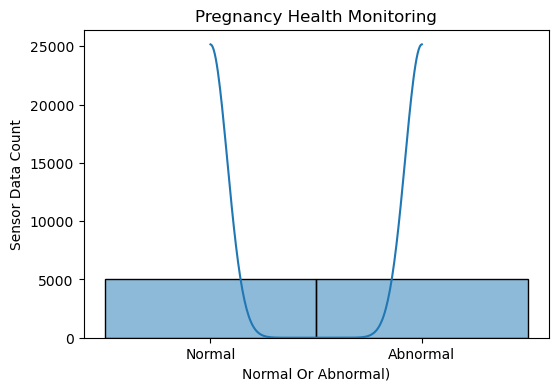

In [116]:
# Display distribution of Pregnancy Health Monitoring
print(df['Condition'].value_counts())
plt.figure(figsize=(6, 4))
sns.histplot(df['Condition'], bins=30, kde=True)
plt.title('Pregnancy Health Monitoring')
plt.xlabel('Normal Or Abnormal)')
plt.ylabel('Sensor Data Count')
plt.show()


Correlation Matrix:
                Pulse   Glucose  BP_Systolic      SPO2  Temperature    Switch
Pulse        1.000000  0.038231     0.038039 -0.025660     0.042793 -0.004389
Glucose      0.038231  1.000000     0.105991 -0.101012     0.044445  0.004148
BP_Systolic  0.038039  0.105991     1.000000 -0.110314     0.067836 -0.001600
SPO2        -0.025660 -0.101012    -0.110314  1.000000    -0.078981 -0.001425
Temperature  0.042793  0.044445     0.067836 -0.078981     1.000000  0.004660
Switch      -0.004389  0.004148    -0.001600 -0.001425     0.004660  1.000000


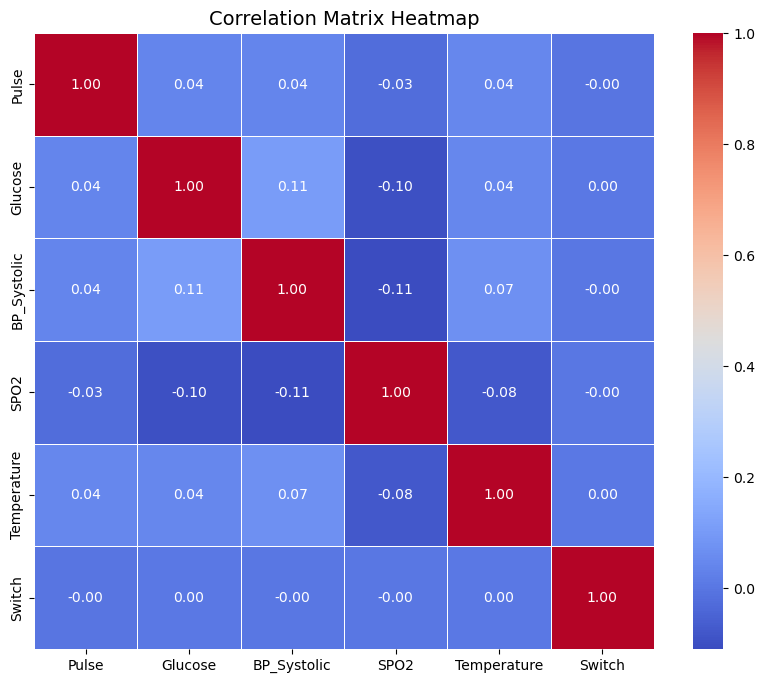

In [118]:
# Filter out non-numeric columns for correlation calculation
numeric_df = df.select_dtypes(include=['number'])

# Calculate and display the correlation matrix
print("\nCorrelation Matrix:")
correlation_matrix = numeric_df.corr()
print(correlation_matrix)

# Plotting the heatmap of the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix Heatmap', fontsize=14)
plt.show()


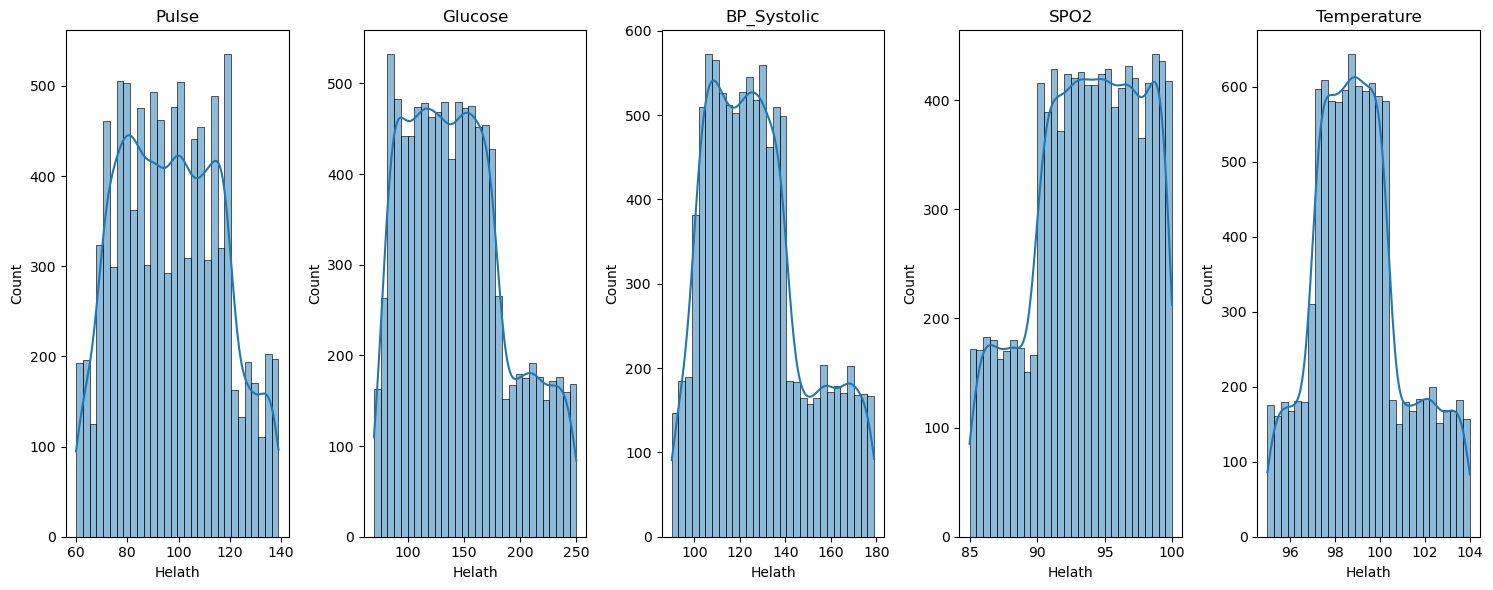

In [120]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize distributions of individual features
plt.figure(figsize=(15, 6))
columns = ['Pulse', 'Glucose', 'BP_Systolic', 'SPO2', 'Temperature'] 

for i, column in enumerate(columns, start=1):
    plt.subplot(1, 5, i)  # 1 row, 4 columns, subplot index i
    sns.histplot(df[column], bins=30, kde=True)
    plt.title(column)
    plt.xlabel('Helath')
    plt.ylabel('Count')

plt.tight_layout()
plt.show()


In [122]:
# Encode the target variable
label_encoder = LabelEncoder()
df['Condition'] = label_encoder.fit_transform(df['Condition'])


In [124]:
import joblib
joblib.dump(label_encoder, 'label_encoder.pkl')

['label_encoder.pkl']

In [126]:
# Split the data into features and target
X = df.drop(columns=['Condition'])
y = df['Condition']


In [128]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [130]:
# Scale the features
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [132]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Create and train the Random Forest model
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test_scaled)

# Evaluate the model
rf_accuracy = accuracy_score(y_test, y_pred_rf) * 100  # Convert to percentage
print(f"Random Forest Accuracy: {rf_accuracy:.2f}%")
print(classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 100.00%
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       988
           1       1.00      1.00      1.00      1012

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



In [134]:
# Save the trained models and scaler
joblib.dump(rf_model, 'rf_model.pkl')
joblib.dump(scaler, 'scaler.pkl')


['scaler.pkl']

In [136]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report

# Create and train the Gradient Boosting model
gb_model = GradientBoostingClassifier(random_state=42, n_estimators=100, learning_rate=0.1)
gb_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_gb = gb_model.predict(X_test_scaled)

# Evaluate the model
gb_accuracy = accuracy_score(y_test, y_pred_gb) * 100  # Convert to percentage
print(f"Gradient Boosting Accuracy: {gb_accuracy:.2f}%")
print(classification_report(y_test, y_pred_gb))
joblib.dump(gb_model, 'gb_model.pkl')


Gradient Boosting Accuracy: 100.00%
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       988
           1       1.00      1.00      1.00      1012

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



['gb_model.pkl']

In [137]:
import pandas as pd
import joblib  # For loading .pkl files

# Load the trained Random Forest model, scaler, and label encoder
rf_model = joblib.load('rf_model.pkl')  # Replace with the correct path if needed
scaler = joblib.load('scaler.pkl')     # Replace with the correct path if needed
label_encoder = joblib.load('label_encoder.pkl')  # Replace with the correct path if needed

def condition(Pulse, Glucose, BP_Systolic, SPO2, Temperature, Switch):

    # Create a DataFrame from the input values
    new_data = pd.DataFrame({
        'Pulse': [Pulse],
        'Glucose': [Glucose],
        'BP_Systolic': [BP_Systolic],
        'SPO2': [SPO2],
        'Temperature': [Temperature],
        'Switch': [Switch],

    })
    
    # Scale the new data using the loaded scaler
    new_data_scaled = scaler.transform(new_data)
    
    # Make predictions using the loaded Random Forest model
    dt_prediction = rf_model.predict(new_data_scaled)
    
    # Convert numerical prediction back to the original label
    result = label_encoder.inverse_transform(dt_prediction)
    
    return result[0]

# Main function to get input from the user and display the prediction
if __name__ == "__main__":
    print("Enter sensor values for prediction:")
    
    try:
        # Get user input
        Pulse = float(input("Pulse: "))
        Glucose = float(input("Glucose: "))
        BP_Systolic = float(input("BP_Systolic: "))
        SPO2 = float(input("SPO2: "))
        Temperature = float(input("Temperature: "))
        Switch = float(input("Switch: "))
        
        # Predict the disaster type
        predicted_result = condition(Pulse, Glucose, BP_Systolic, SPO2, Temperature, Switch)
        
        # Display the prediction
        print("\nPredicted Result:", predicted_result)
    except Exception as e:
        print("\nError:", str(e))


Enter sensor values for prediction:


Pulse:  10
Glucose:  20
BP_Systolic:  12
SPO2:  60
Temperature:  36
Switch:  1



Predicted Result: Abnormal
